creating pivot view sorted by region for the sampled_par.xlsx files, then plot by 
regions: st johns, avalon, western, central

In [55]:
import os
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import math
import datetime
import matplotlib.patches as mpatches
import re
import numpy as np

In [56]:
increment = 19

In [57]:
folder = r"C:\Users\CAMG038492\OneDrive - WSP O365\Documents\Climate Data\NF Power GIS\Output Samples\uploaded"
paralist = [t[8:-5] for t in os.listdir(folder) if t.startswith("sampled_") and not t.endswith(".csv")]
# todo later:    storms tropicalstorms waves
para = paralist[increment:][0]
print(para)
path = os.path.join(folder, "sampled_"+para+".xlsx")
path

sfcWindmax


'C:\\Users\\CAMG038492\\OneDrive - WSP O365\\Documents\\Climate Data\\NF Power GIS\\Output Samples\\uploaded\\sampled_sfcWindmax.xlsx'

In [58]:
sheets = pd.read_excel(path, sheet_name=None)
#sheets = pd.read_excel(r"C:\Users\CAMG038492\OneDrive - WSP O365\Documents\Climate Data\NF Power GIS\Output Samples\uploaded\archive\sampled_sfcWindmax.xlsx", sheet_name = None)

In [59]:
cdf = pd.DataFrame()
for name, df in sheets.items():
    if name != "metadata":
        for col in df.columns:
            if col not in cdf.columns:
                cdf[col] = df[col]
cdf.head()

,File Name,X,Y,Z,Name,Region,Land,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp10.nc,...,sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp90.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annstd_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p10sim_2021-2050_annp10sim_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p90sim_2021-2050_annp90sim_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp10.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp90.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annstd_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p10sim_2041-2070_annp10sim_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p90sim_2041-2070_annp90sim_30yavg.nc
0,Generation_Avalon.csv,-53.215556,47.775177,37.0,{D1A64ECC-9AA7-4947-AB92-5490AD503118},Avalon,land,1.0,0.493903,0.458098,...,0.525411,0.493021,-0.148867,1.114797,1.0,0.448140,0.523720,0.493336,-0.146306,1.118166
1,Generation_Avalon.csv,-53.194103,48.006468,90.0,{CA8B9EE1-9580-4BFB-89C2-B57BBF1810D8},Avalon,land,1.0,0.560219,0.518400,...,0.596122,0.494827,-0.079943,1.188351,1.0,0.524295,0.597206,0.494286,-0.072703,1.194204
2,Generation_Avalon.csv,-53.375804,47.862770,NaN,{0257D205-6BE3-477C-8747-69CD2BC0C670},Avalon,land,1.0,0.538777,0.496132,...,0.575852,0.497650,-0.105222,1.170305,1.0,0.500606,0.578222,0.497362,-0.097981,1.176809
3,Generation_Avalon.csv,-53.210355,48.029139,12.0,{C27971B6-7D43-47C9-B390-7326CCDBACFF},Avalon,land,1.0,0.591142,0.547141,...,0.629069,0.491280,-0.042934,1.216267,1.0,0.557326,0.629524,0.490361,-0.034998,1.221847
4,Generation_Avalon.csv,-53.090261,48.498080,16.0,{11B4AC5A-6206-4AD7-9F18-6B7A6433FC14},Avalon,land,1.0,0.449244,0.413078,...,0.480615,0.476270,-0.165583,1.055147,1.0,0.422254,0.482389,0.477393,-0.159482,1.064125


In [60]:
# region filtering
regions = {
    "St Johns" : ["St. John's", "St.John's"],
    "Avalon" : ['Avalon', 'Eastern'],
    "Central" : ['Central', 'Bonavista', 'Burin', 'Gander', 'Grand Falls'],
    "Western" : ['Western', 'Corner Brook', 'Stephenville']
}
mapping = {}
for v, synonyms in regions.items():
    for synonym in synonyms:
        mapping[synonym] = v  # map each synonym to the standard name

In [61]:
cdf['Region_summarized'] = cdf['Region'].map(mapping)
cdf

,File Name,X,Y,Z,Name,Region,Land,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp10.nc,...,sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annstd_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p10sim_2021-2050_annp10sim_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p90sim_2021-2050_annp90sim_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp10.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp90.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annstd_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p10sim_2041-2070_annp10sim_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_p90sim_2041-2070_annp90sim_30yavg.nc,Region_summarized
0,Generation_Avalon.csv,-53.215556,47.775177,37.0,{D1A64ECC-9AA7-4947-AB92-5490AD503118},Avalon,land,1.0,0.493903,0.458098,...,0.493021,-0.148867,1.114797,1.0,0.448140,0.523720,0.493336,-0.146306,1.118166,Avalon
1,Generation_Avalon.csv,-53.194103,48.006468,90.0,{CA8B9EE1-9580-4BFB-89C2-B57BBF1810D8},Avalon,land,1.0,0.560219,0.518400,...,0.494827,-0.079943,1.188351,1.0,0.524295,0.597206,0.494286,-0.072703,1.194204,Avalon
2,Generation_Avalon.csv,-53.375804,47.862770,NaN,{0257D205-6BE3-477C-8747-69CD2BC0C670},Avalon,land,1.0,0.538777,0.496132,...,0.497650,-0.105222,1.170305,1.0,0.500606,0.578222,0.497362,-0.097981,1.176809,Avalon
3,Generation_Avalon.csv,-53.210355,48.029139,12.0,{C27971B6-7D43-47C9-B390-7326CCDBACFF},Avalon,land,1.0,0.591142,0.547141,...,0.491280,-0.042934,1.216267,1.0,0.557326,0.629524,0.490361,-0.034998,1.221847,Avalon
4,Generation_Avalon.csv,-53.090261,48.498080,16.0,{11B4AC5A-6206-4AD7-9F18-6B7A6433FC14},Avalon,land,1.0,0.449244,0.413078,...,0.476270,-0.165583,1.055147,1.0,0.422254,0.482389,0.477393,-0.159482,1.064125,Avalon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380979,Underground_Western.csv,-58.590983,48.553030,22.0,{F91F5CCE-BF23-4B9D-A033-600369ED4B0C},Stephenville,land,1.0,0.161696,0.137754,...,0.366950,-0.294150,0.646379,1.0,0.160069,0.213614,0.377033,-0.296346,0.670029,Western
380980,Underground_Western.csv,-58.591051,48.553225,23.0,{00B3B2A8-E054-4A73-B2C5-2765DD9E9B30},Stephenville,land,1.0,0.161696,0.137754,...,0.366950,-0.294150,0.646379,1.0,0.160069,0.213614,0.377033,-0.296346,0.670029,Western
380981,Underground_Western.csv,-58.591197,48.552998,22.0,{226D7C79-E32E-4AB6-A256-48C829595FB1},Stephenville,land,1.0,0.161696,0.137754,...,0.366950,-0.294150,0.646379,1.0,0.160069,0.213614,0.377033,-0.296346,0.670029,Western
380982,Underground_Western.csv,-58.591257,48.553064,22.0,{09389E4B-9461-49FF-989D-278B58EB6A7E},Stephenville,land,1.0,0.161696,0.137754,...,0.366950,-0.294150,0.646379,1.0,0.160069,0.213614,0.377033,-0.296346,0.670029,Western


In [62]:
canrcm4list = ['humidex', 'pr-50mm','prsn-50mm', 'pr','prsn', 'ros', 'sfcWindmax','sfcWindmax-anwindgust63', 'ros-anrainonsnow1', 'sfcWindmax-anwindspeed63']
awkcanrcm4list = ['drydays','humidex30','pr50','prsn50','prfr']

In [63]:
datacols = [t for t in cdf.columns if t.startswith(para) and not "45_" in t and not "126_" in t]
datacols


['sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmax_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp10.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp90.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annstd_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_p10sim_1976-2005_annp10sim_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_p90sim_1976-2005_annp90sim_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmax_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp10.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp90.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annstd_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_p10sim_2021-2050_annp10sim_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_p90sim_2021-2050_annp90sim_30yavg.nc',
 'sfcWindmax-anwindgust

In [64]:
if para in ['storms','tropicalstorms','flood','stormsurge','waves']:
    datacols = cdf.columns[7:-1]
    datacols = [t for t in datacols if '45_' not in t]
if para == 'waves':
    datacols = [t for t in datacols if 'corrected' in t and 'Hsavg' in t]
if para in canrcm4list:
    #if para not in ['prsn','pr']:
        #pass
    datacols = [s for s in datacols if 'annsum' not in s and 'annstd' not in s]
    #else:
    #datacols = [s for s in datacols if 'annsum' in s]
if para == 'sfcWindmax':
    datacols = [s for s in datacols if "anwindgust63" in s]
    datacols = [t for t in datacols if 'annp' not in t]
    para = 'sfcWindmax-anwindgust63'
if para == 'ros':
    datacols = [s for s in datacols if "anrainonsnow1_" in s and "annp" not in s]
    para = 'ros-anrainonsnow1'
if para == 'prsn-50mm':
    datacols = [s for s in datacols if "annp" not in s]


In [65]:
datacols

['sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmax_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp10.nc',
 'sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp90.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmax_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp10.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp90.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmax_30yavg.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp10.nc',
 'sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp90.nc']

In [66]:
grouped_mean = cdf.groupby('Region_summarized')[datacols].mean()
grouped_min = cdf.groupby('Region_summarized')[datacols].min()
grouped_max = cdf.groupby('Region_summarized')[datacols].max()
grouped_mean.transpose().to_csv(os.path.join(folder,"plots",f"grouped_{para}_regionmean.csv"))
grouped_min.transpose().to_csv(os.path.join(folder,"plots",f"grouped_{para}_regionmin.csv"))
grouped_max.transpose().to_csv(os.path.join(folder,"plots",f"grouped_{para}_regionmax.csv"))

In [67]:
# Dark mode style
plt.style.use('dark_background')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': 'white',
    'figure.facecolor': '#222222',
    'axes.facecolor': '#222222',
    'grid.color': '#555555'
})

In [68]:
df_mean = grouped_mean
df_min = grouped_min
df_max = grouped_max
lowerr = df_mean-df_min
higerr = df_max-df_mean
regions = grouped_mean.index.tolist()
numeric_df = grouped_mean
df_mean

,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp10.nc,sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp90.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp10.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp90.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmax_30yavg.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp10.nc,sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp90.nc
Region_summarized,,,,,,,,,,
Avalon,1.0,0.332610,0.297574,0.367647,1.0,0.295277,0.365265,1.0,0.304992,0.369183
Central,1.0,0.201277,0.172361,0.230193,1.0,0.175866,0.235971,1.0,0.189648,0.245610
St Johns,1.0,0.473125,0.437049,0.509202,1.0,0.420658,0.505530,1.0,0.429106,0.508538
Western,1.0,0.193306,0.168367,0.218245,1.0,0.171814,0.229497,1.0,0.184444,0.237551


In [69]:
order_map = {'min': 0, 'p5': 0, 'p10': 1, 'p50': 2, 'avg':3, 'p90': 4, 'p95': 5, 'max':6,'': 7}
labels_data = []
seen = []
for col in numeric_df.columns:
    if para == 'flashrate':
        scen = 'CESM2' if 'CESM2' in col else ('UKESM' if 'UKESM' in col else ('GISS' if 'GISS' in col else ''))
    elif para in canrcm4list:
        scen = 'min' if 'annmin' in col else ('max' if 'annmax' in col else ('p10' if 'p10' in col else ('p90' if 'p90' in col else('p50' if 'annmean' in col else ''))))
    elif 'p95' in col: scen = 'p95'
    elif 'p90' in col: scen = 'p90'
    elif 'p50' in col: scen = 'p50'
    elif 'p10' in col: scen = 'p10'
    elif 'p5_' in col: scen = 'p5'
    elif para == 'waves':
        scen = 'max' if 'max' in col else ('min' if 'min' in col else ('mean' if 'mean' in col else ''))
    else:
        if para in awkcanrcm4list:
            if "annmax" in col: scen = "max"
            elif "annmin" in col: scen = "min"
            else: scen = 'mean'
        else: scen = ''
    try: date = re.search(r'\d{4}-\d{4}', col).group(0)
    except: date = re.search(r'\d{6}-\d{6}', col).group(0)
    label = f'{scen}_{date}' if scen else date
    print(col,label)
    if label in seen:
        raise ValueError(f"duplicate found {label} for {col}, rerun")
    else:
        seen.append(label)
    labels_data.append({'col': col, 'scenario': scen, 'date': date, 'label': label, 'order': order_map.get(scen, 3)})

labels_data_sorted = sorted(labels_data, key=lambda x: (x['date'], x['order']))
sorted_cols = [d['col'] for d in labels_data_sorted]
sorted_labels = [d['label'] for d in labels_data_sorted]


sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmax_30yavg.nc max_1976-2005
sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc p50_1976-2005
sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp10.nc p10_1976-2005
sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp90.nc p90_1976-2005
sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmax_30yavg.nc max_2021-2050
sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp10.nc p10_2021-2050
sfcWindmax-anwindgust63_CanRCM4_rcp85_2021-2050_annmean_30yp90.nc p90_2021-2050
sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmax_30yavg.nc max_2041-2070
sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp10.nc p10_2041-2070
sfcWindmax-anwindgust63_CanRCM4_rcp85_2041-2070_annmean_30yp90.nc p90_2041-2070


In [70]:
c_default = '#CCCCCC'
c_p5 = '#E69F00'
c_p50 = '#56B4E9'
c_p95 = '#009E73'
sorted_colors = [c_p95 if d['scenario'] == 'p95' or d['scenario'] == 'p90' or d['scenario'] == 'max'
                 else c_p50 if d['scenario'] == 'p50' or d['scenario'] == 'mean'
                 else c_p5 if d['scenario'] == 'p5' or d['scenario'] == 'p10' or d['scenario'] == 'min'
                 else c_default for d in labels_data_sorted]

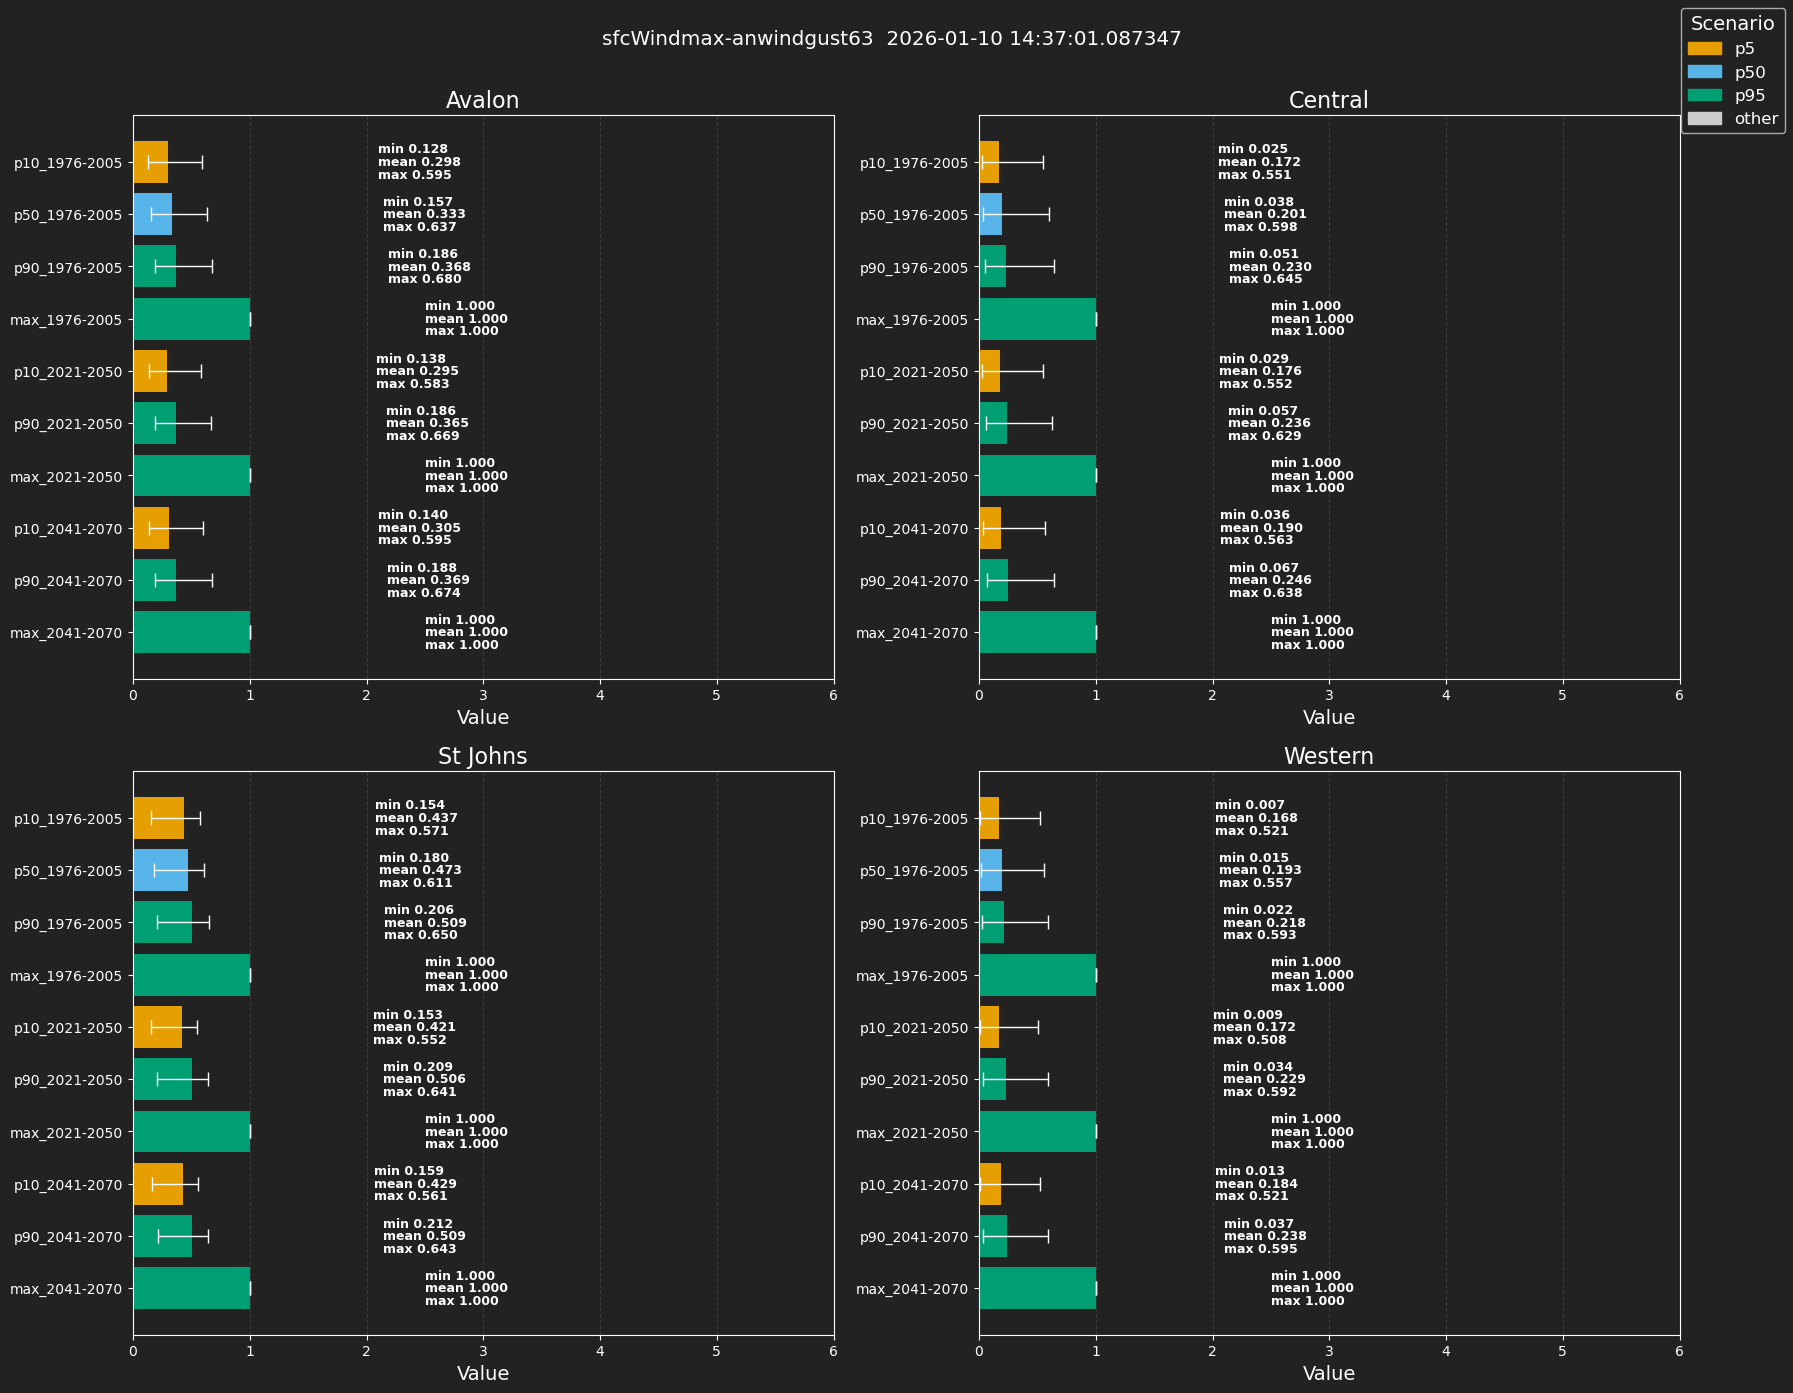

In [71]:
n = len(df_mean)
rows = int(math.ceil(math.sqrt(n)))
cols = int(math.ceil(n / rows))
fig, axes = plt.subplots(rows, cols, figsize=(cols*9, rows*7))
axes = axes.flatten() if n > 1 else [axes]

for i in range(n):
    vals = df_mean.iloc[i][sorted_cols].values

    whiskers = True
    if whiskers:
        low = lowerr.iloc[i][sorted_cols].values
        hig = higerr.iloc[i][sorted_cols].values
        xerr = [low, hig]
        bars = axes[i].barh(sorted_labels, vals, color=sorted_colors, xerr=xerr, capsize = 5, error_kw={'ecolor': 'white', 'elinewidth': 1})
    if not whiskers:
        bars = axes[i].barh(sorted_labels, vals, color=sorted_colors)

    axes[i].invert_yaxis()  # first label at top
    axes[i].set_title(regions[i])
    axes[i].set_xlabel('Value')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

    if whiskers:
        try:
            max_end = np.nanmax(vals + hig)
            texts = [f'{v:.3f}' for v in vals]
            margin = (max(len(s) for s in texts))
            axes[i].set_xlim(0, max_end + margin)
        except: pass

    for j,bar in enumerate(bars):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2.
        offset = bar.get_height()*0.3

        if whiskers:
            hwid = hig[j] + 1.5
            axes[i].text(width+hwid, y-offset, f'min {width-low[j]:.3f}', va='center', ha='left', fontsize=9, fontweight='bold', color='white')
            axes[i].text(width+hwid, y, f'mean {width:.3f}', va='center', ha='left', fontsize=9, fontweight='bold', color='white')
            axes[i].text(width+hwid, y+offset, f'max {width+hig[j]:.3f}', va='center', ha='left', fontsize=9, fontweight='bold', color='white')

        if not whiskers:
            axes[i].text(width, y, f'{width:.3f}', va='center', ha='left', fontsize=9, fontweight='bold', color='white')


for j in range(n, len(axes)):
    fig.delaxes(axes[j])

legend_handles = [
    mpatches.Patch(color=c_p5, label='p5'),
    mpatches.Patch(color=c_p50, label='p50'),
    mpatches.Patch(color=c_p95, label='p95'),
    mpatches.Patch(color=c_default, label='other')
]
leg = fig.legend(handles=legend_handles, loc='upper right', title='Scenario', fontsize=12, title_fontsize=14)
for text in leg.get_texts():
    text.set_color('white')
leg.get_title().set_color('white')

plt.tight_layout(rect=[0, 0, .95, .95])
plt.suptitle(para + "  " + str(datetime.datetime.now()))
plt.savefig(os.path.join(folder,"plots",f"plotted_whisker_{para}.png"))
plt.show()


In [72]:
increment += 1
print(f"next {paralist[increment:][0]}")

next SPEI
